# Hierarchical Clustering from Scratch

## Objectives

- Understand Agglomerative Hierarchical Clustering.
- Implement hierarchical clustering using NumPy.
- Understand cluster merging and linkage distance.
- Visualize the resulting hierarchy using a dendrogram.
- Compare the implementation with Scikit-Learn.

## Hierarchical Clustering Intuition

Agglomerative Hierarchical Clustering starts with every data point as its
own cluster.

It repeatedly:

1. Finds the two closest clusters.
2. Merges them.
3. Recalculates the distances between clusters.
4. Continues until the desired number of clusters remains.

This implementation uses **single linkage**, where the distance between
two clusters is the minimum distance between any two points in those clusters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

In [2]:
X, _ = make_blobs(
    n_samples=200,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,6.505653,2.447003
1,-5.128943,9.836189
2,-8.850575,6.426269
3,-10.286412,5.916059
4,-7.468992,-6.030507


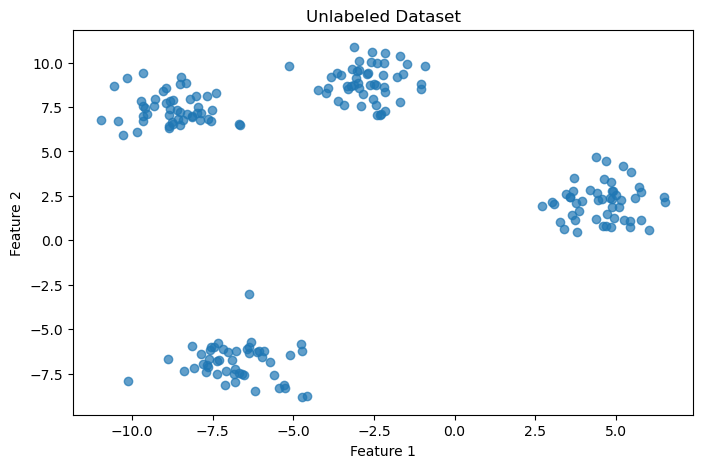

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled Dataset")

plt.show()

In [4]:
class HierarchicalClusteringScratch:

    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.labels_ = None
        self.merges_ = None

    def _distance(self, cluster_a, cluster_b, X):
        points_a = X[cluster_a]
        points_b = X[cluster_b]

        distances = np.sqrt(
            ((points_a[:, None, :] - points_b[None, :, :]) ** 2).sum(axis=2)
        )

        return np.min(distances)

    def fit(self, X):
        X = np.asarray(X)

        clusters = [[i] for i in range(len(X))]
        merges = []

        next_cluster_id = len(X)

        while len(clusters) > self.n_clusters:

            min_distance = np.inf
            merge_pair = None

            for i in range(len(clusters)):
                for j in range(i + 1, len(clusters)):

                    distance = self._distance(
                        clusters[i],
                        clusters[j],
                        X
                    )

                    if distance < min_distance:
                        min_distance = distance
                        merge_pair = (i, j)

            i, j = merge_pair

            new_cluster = clusters[i] + clusters[j]

            merges.append([
                i,
                j,
                min_distance,
                len(new_cluster)
            ])

            clusters.pop(j)
            clusters.pop(i)

            clusters.append(new_cluster)

            next_cluster_id += 1

        self.labels_ = np.zeros(len(X), dtype=int)

        for cluster_id, cluster in enumerate(clusters):
            for index in cluster:
                self.labels_[index] = cluster_id

        self.merges_ = merges

        return self

    def predict(self, X):
        return self.labels_

In [5]:
hierarchical = HierarchicalClusteringScratch(
    n_clusters=4
)

hierarchical.fit(X)

labels = hierarchical.labels_

print("Cluster labels:")
print(labels[:20])

Cluster labels:
[0 2 1 1 3 3 0 1 0 3 3 0 0 3 3 3 2 1 3 3]


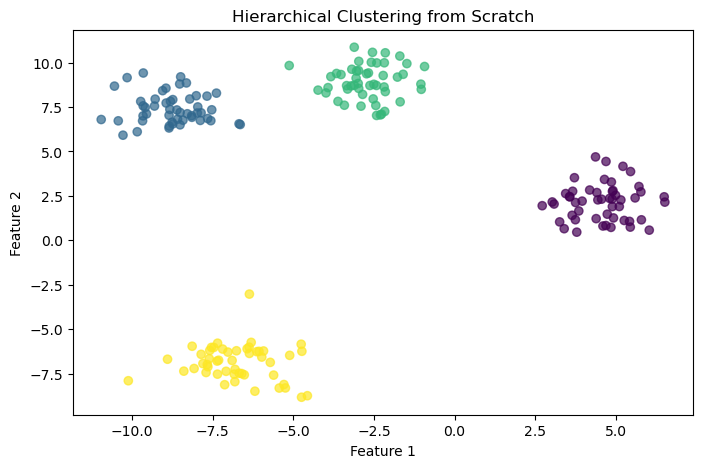

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering from Scratch")

plt.show()

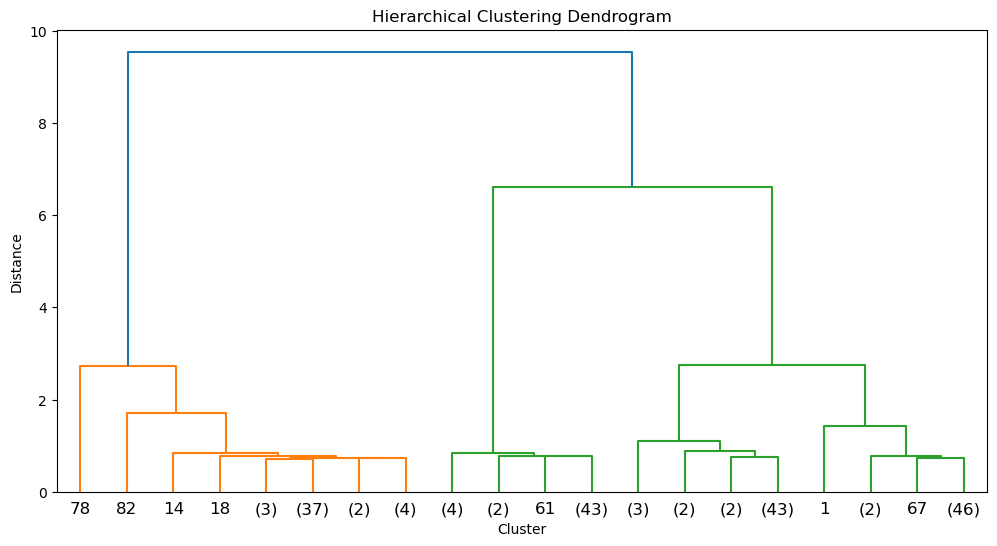

In [7]:
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(
    X,
    method="single"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20
)

plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [8]:
silhouette = silhouette_score(
    X,
    labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.7947822916132821


In [9]:
sklearn_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="single"
)

sklearn_labels = sklearn_model.fit_predict(X)

comparison = pd.DataFrame({
    "Implementation": [
        "From Scratch",
        "Scikit-Learn"
    ],
    "Silhouette Score": [
        silhouette_score(X, labels),
        silhouette_score(X, sklearn_labels)
    ]
})

comparison

,Implementation,Silhouette Score
0,From Scratch,0.794782
1,Scikit-Learn,0.794782


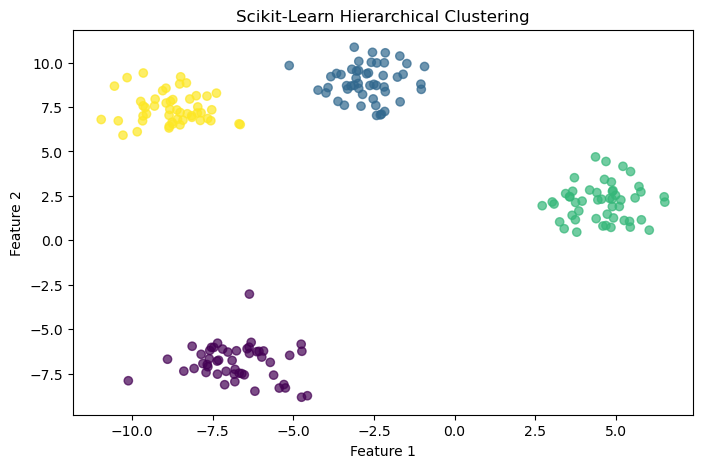

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=sklearn_labels,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scikit-Learn Hierarchical Clustering")

plt.show()

## Conclusion

- Hierarchical clustering builds a hierarchy of clusters.
- Agglomerative clustering starts with individual samples and repeatedly
  merges the closest clusters.
- Single linkage uses the minimum distance between points from two clusters.
- A dendrogram provides a visual representation of the clustering hierarchy.
- The number of clusters can be selected by cutting the hierarchy at an
  appropriate distance.
- Hierarchical clustering does not require centroids like K-Means.

## Limitations

- Computational cost increases significantly with the number of samples.
- Single linkage can produce chain-like clusters.
- The choice of linkage method can strongly affect the result.